In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test

data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [2]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

baseline_hidden_sizes = (128, 64)
detector = build_detector(
    train_paths,
    history=history,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    hidden_sizes=baseline_hidden_sizes,
)

# train_results = [detector.detect(path) for path in train_paths[:3]]
# test_results = [detector.detect(path) for path in test_paths[:3]]

disp = detector.prediction_confusion_matrix(test_paths[1])

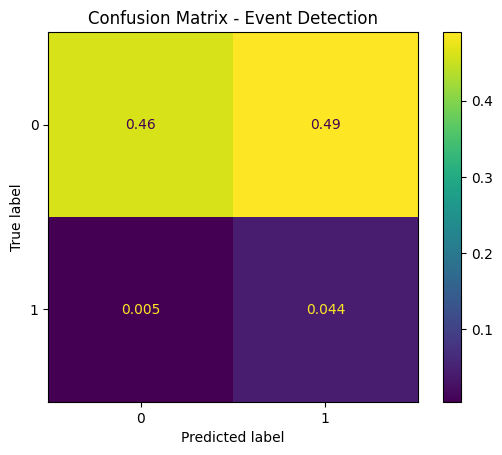

In [3]:
disp.plot()
plt.title('Confusion Matrix - Event Detection')
plt.show()
